In [1]:
# ==========================================
# 问题二：
# 跨省高考成绩分布比较
# 描述统计 + KDE辅助 + Wasserstein距离
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import (
    wasserstein_distance,
    skew,
    kurtosis
)
from sklearn.neighbors import KernelDensity


# ===============================
# 中文字体
# ===============================
plt.rcParams["font.sans-serif"]=["SimHei"]
plt.rcParams["axes.unicode_minus"]=False


# ===============================
# 1. 文件
# ===============================
files={
"山西2025物理":"shanxi_2025_physics.csv",
"山西2025历史":"shanxi_2025_history.csv",
"山西2026物理":"shanxi_2026_physics.csv",
"山西2026历史":"shanxi_2026_history.csv",
"河北2025物理":"hebei_2025_physics.csv",
"河北2025历史":"hebei_2025_history.csv",
"河北2026物理":"hebei_2026_physics.csv",
"河北2026历史":"hebei_2026_history.csv",
"浙江2025":"zhejiang_2025.csv",
"浙江2026":"zhejiang_2026.csv"
}

# ===============================
# 2. 本科线
# ===============================
line_df=pd.read_csv("undergraduate_line.csv")
cutoff=dict(zip(files.keys(),line_df["本科线"]))


# ===============================
# 3. 读取成绩
# ===============================
def load_score(file,name):
    df=pd.read_csv(file)
    df=df[["分数","本分人数"]]
    # 本科线上
    df=df[df["分数"]>=cutoff[name]]
    score=np.repeat(df["分数"].values,df["本分人数"].astype(int).values)
    return score
samples={}
for name,file in files.items():
    samples[name]=load_score(file,name)
print("数据读取完成")


# ===============================
# 4. 描述统计
# ===============================
result=[]
for name,data in samples.items():
    result.append({"样本":name,"本科线上线人数":len(data),"平均分":np.mean(data),
                   "标准差":np.std(data),"偏度":skew(data),"峰度":
        kurtosis(data,fisher=False)})
stat_df=pd.DataFrame(result)


# ==========================================
# 4.1 追加本科上线率、特控上线率
# ==========================================
line_df=pd.read_csv("undergraduate_lines.csv",encoding="utf-8")
# 构造样本名称，与stat_df保持一致
line_df["样本"]=(line_df["省份"]+line_df["年份"].astype(str)+line_df["方向"])
# 浙江名称特殊处理
line_df.loc[line_df["省份"]=="浙江","样本"]=("浙江"+line_df["年份"].astype(str))
# 计算本科上线率
line_df["本科上线率"]=(line_df["本科线对应位次"]/line_df["报考人数"])
# 计算特控上线率
line_df["特控上线率"]=(line_df["特控线对应位次"]/line_df["报考人数"])
# 合并
stat_df=stat_df.merge(line_df[["样本","本科上线率","特控上线率"]],on="样本",how="left")
print("\n==========扩展描述统计==========")
display(stat_df.round(4))


# ===============================
# 5. KDE拟合
# （只计算，不绘图）
# ===============================
kde_result={}
for name,data in samples.items():
    kde=KernelDensity(kernel="gaussian",bandwidth=3)
    kde.fit(data.reshape(-1,1))
    kde_result[name]=kde
print("KDE拟合完成")


# ===============================
# 6. Wasserstein距离
# ===============================
names=list(samples.keys())
W=pd.DataFrame(np.zeros((len(names),len(names))),
    index=names,
    columns=names)
for i in range(len(names)):
    for j in range(len(names)):
        W.iloc[i,j]=wasserstein_distance(samples[names[i]],samples[names[j]])
print("\n==========Wasserstein距离==========")
display(W.round(3))


# ==========================================
# 10. KDE分布特征提取
# ==========================================
kde_features=[]
# 选择观察分数点
score_points=[450,500,550,600]
for name,kde in kde_result.items():
    # 分数范围
    x=np.arange(400,701)
    # KDE密度
    density=np.exp(kde.score_samples(x.reshape(-1,1)))
    # 离散归一化
    density=density/density.sum()
    # 累计分布
    cdf=np.cumsum(density)
    row={"样本":name}
    # --------------------------
    # 密度值
    # --------------------------
    for s in score_points:
        row[f"{s}分密度"]=density[s-400]
    # --------------------------
    # 高分比例
    # --------------------------
    for s in [500,550,600]:
        row[f"{s}分以上比例"]=1-cdf[s-400]
    kde_features.append(row)
kde_df=pd.DataFrame(kde_features)
print("\n==========KDE分布特征==========")
display(kde_df.round(4))

数据读取完成

==========扩展描述统计==========


,样本,本科线上线人数,平均分,标准差,偏度,峰度,本科上线率,特控上线率
0,山西2025物理,120275,508.6806,58.9327,0.5555,2.5662,0.6509,0.3007
1,山西2025历史,35869,514.4161,47.0907,0.5501,2.6111,0.3364,0.1094
2,山西2026物理,129352,511.2320,65.1460,0.2863,2.2097,0.7727,0.3195
3,山西2026历史,35378,496.8484,55.3259,0.4605,2.4721,0.5607,0.1349
4,河北2025物理,224230,535.0292,49.2379,0.5029,2.5016,0.6176,0.4469
5,河北2025历史,64868,536.2347,41.8850,0.6130,2.6003,0.2663,0.1393
6,河北2026物理,237416,530.6412,54.2241,0.4104,2.4248,0.6764,0.4081
7,河北2026历史,64025,540.4781,39.1137,0.6285,2.6627,0.2766,0.1212
8,浙江2025,184372,569.2883,48.4943,0.2893,2.2012,0.4586,0.1533
9,浙江2026,184424,571.5651,47.7712,0.3054,2.1936,0.4563,0.1523


KDE拟合完成

==========Wasserstein距离==========


,山西2025物理,山西2025历史,山西2026物理,山西2026历史,河北2025物理,河北2025历史,河北2026物理,河北2026历史,浙江2025,浙江2026
山西2025物理,0.000,11.473,7.435,11.832,26.389,28.616,21.961,32.984,60.610,62.888
山西2025历史,11.473,0.000,16.003,17.568,20.613,21.819,16.225,26.062,54.872,57.149
山西2026物理,7.435,16.003,0.000,15.230,23.817,27.530,19.409,31.860,58.056,60.333
山西2026历史,11.832,17.568,15.230,0.000,38.181,39.386,33.793,43.630,72.440,74.717
河北2025物理,26.389,20.613,23.817,38.181,0.000,6.152,5.115,9.544,34.259,36.536
河北2025历史,28.616,21.819,27.530,39.386,6.152,0.000,10.871,4.377,33.054,35.330
河北2026物理,21.961,16.225,19.409,33.793,5.115,10.871,0.000,14.586,38.651,40.929
河北2026历史,32.984,26.062,31.860,43.630,9.544,4.377,14.586,0.000,28.810,31.087
浙江2025,60.610,54.872,58.056,72.440,34.259,33.054,38.651,28.810,0.000,2.306
浙江2026,62.888,57.149,60.333,74.717,36.536,35.330,40.929,31.087,2.306,0.000



==========KDE分布特征==========


,样本,450分密度,500分密度,550分密度,600分密度,500分以上比例,550分以上比例,600分以上比例
0,山西2025物理,0.0062,0.0059,0.0041,0.0023,0.4968,0.2443,0.0845
1,山西2025历史,0.0072,0.0077,0.0053,0.0021,0.5573,0.2292,0.0514
2,山西2026物理,0.0048,0.0052,0.0043,0.0029,0.5297,0.2910,0.1086
3,山西2026历史,0.0064,0.0061,0.0040,0.0017,0.4385,0.1846,0.0449
4,河北2025物理,0.0000,0.0075,0.0062,0.0034,0.7085,0.3557,0.1175
5,河北2025历史,0.0000,0.0097,0.0070,0.0035,0.7576,0.3411,0.0889
6,河北2026物理,0.0052,0.0065,0.0058,0.0033,0.6614,0.3478,0.1209
7,河北2026历史,0.0000,0.0107,0.0078,0.0034,0.8279,0.3652,0.0892
8,浙江2025,0.0000,0.0062,0.0067,0.0060,0.9330,0.6047,0.2790
9,浙江2026,0.0000,0.0061,0.0068,0.0061,0.9571,0.6205,0.2890


findfont: Failed to find font weight bold, now using 400.


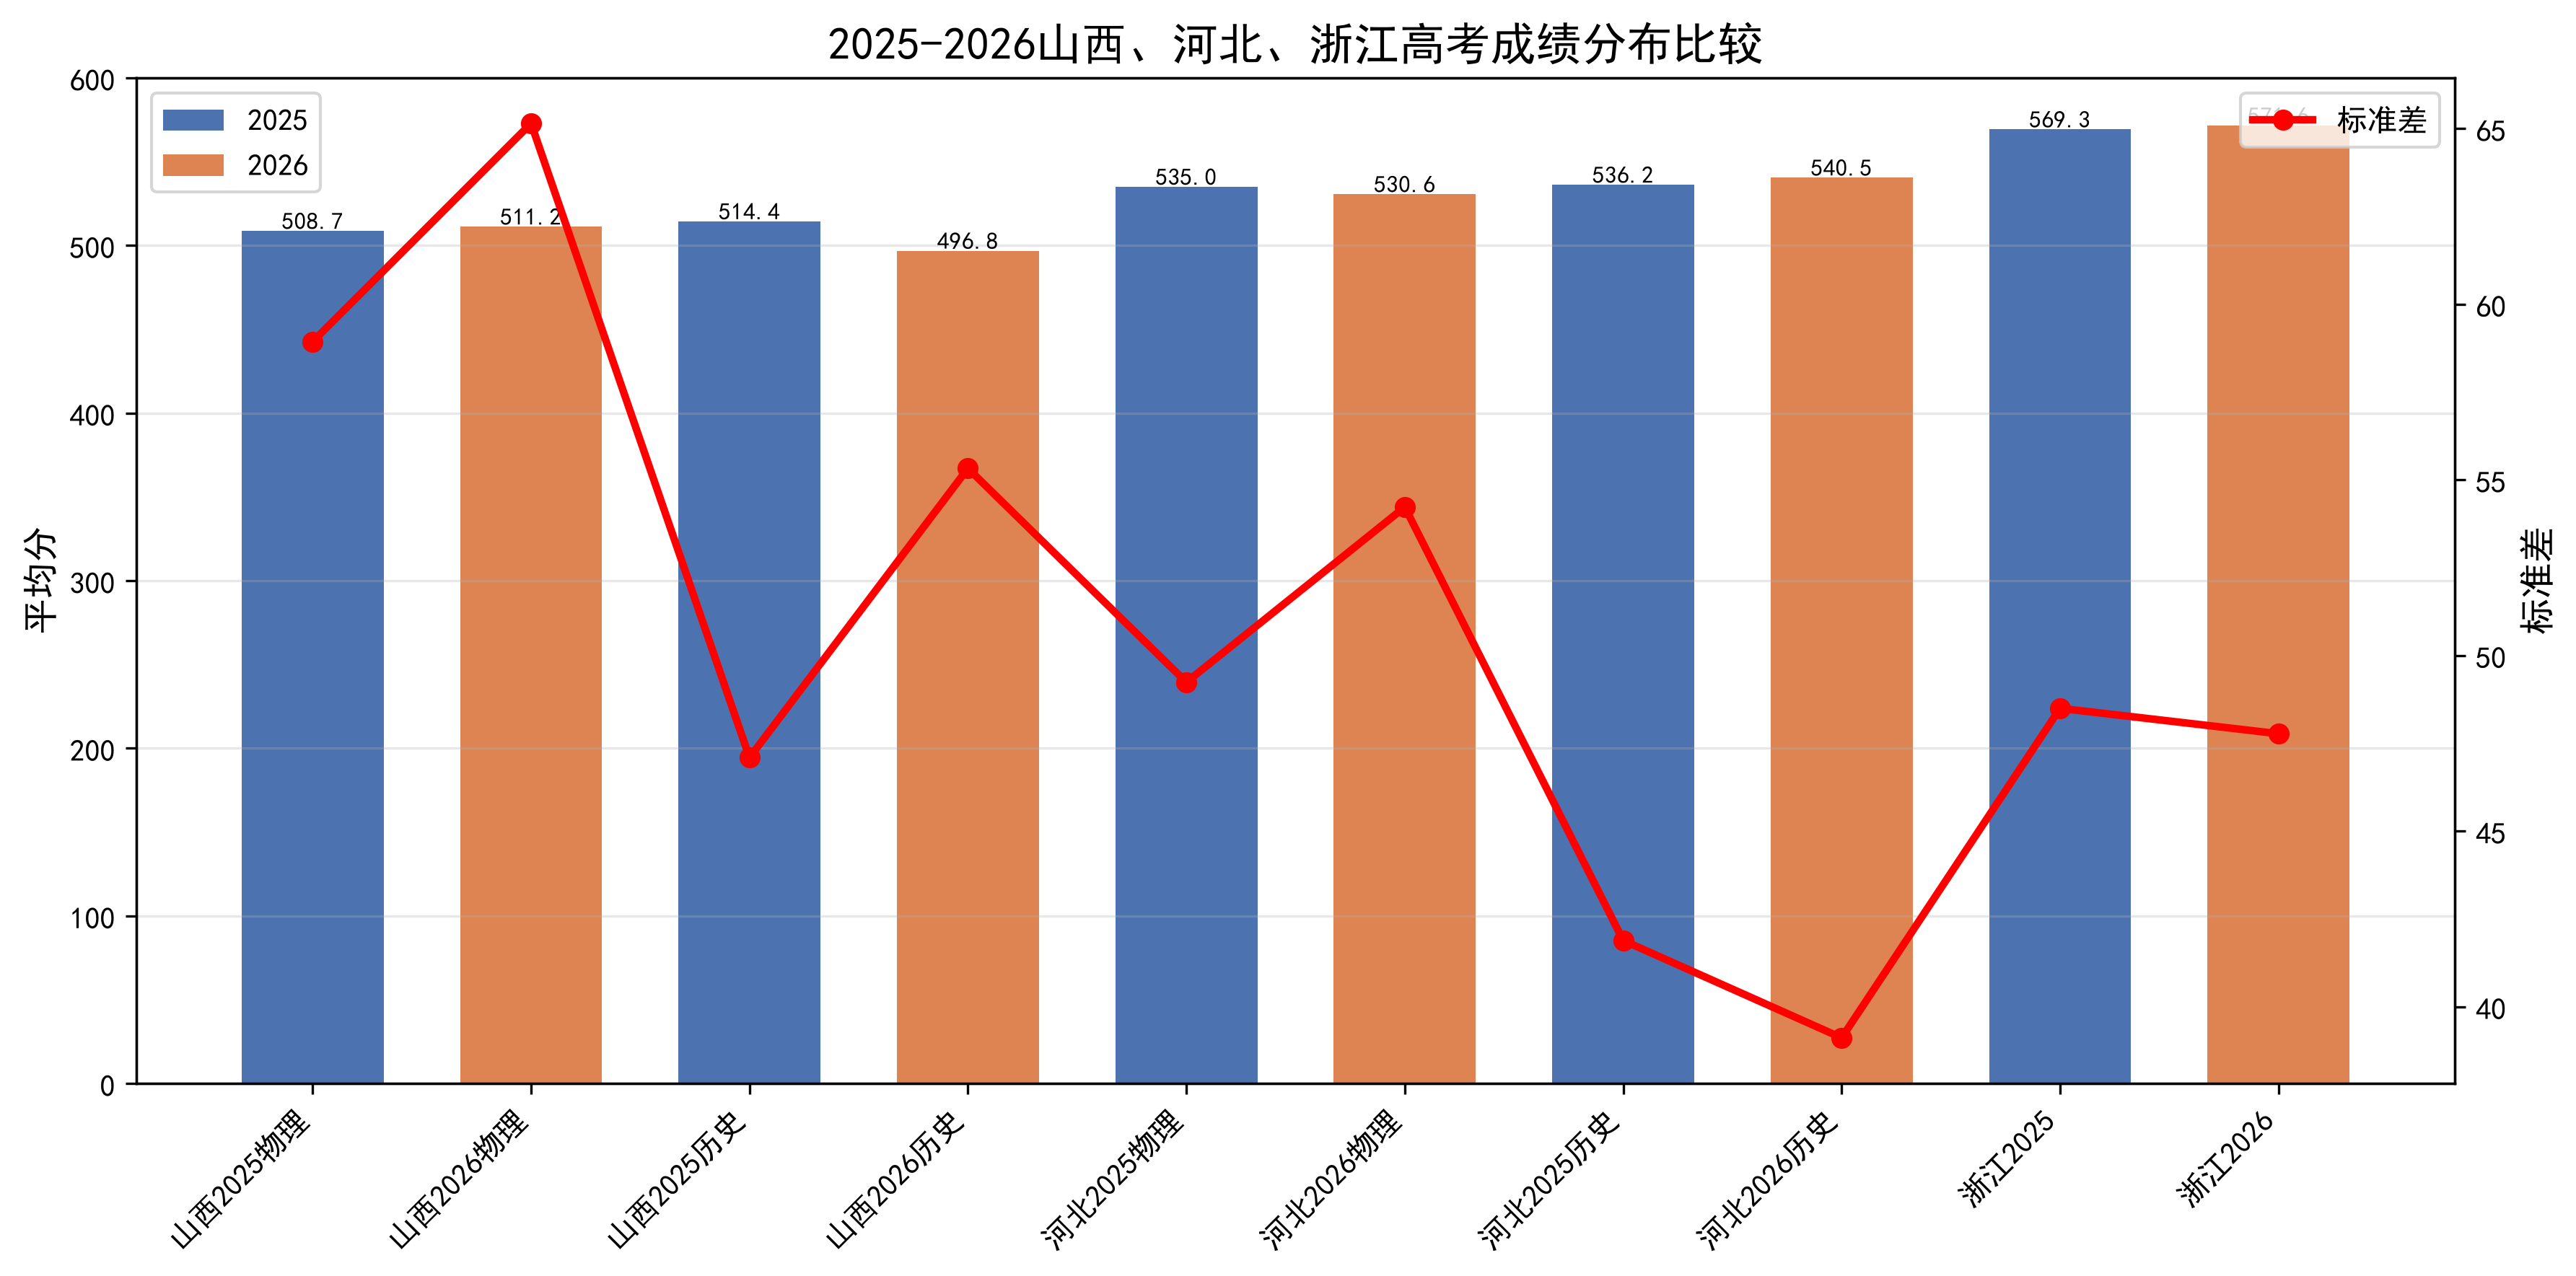

In [2]:
# ==========================================
# 平均分 + 标准差综合比较图
# 物理/历史合并
# ==========================================
def mean_std_compare_plot(df):
    # -------------------------
    # 数据整理
    # -------------------------
    plot_df=df.copy()
    # 排序
    order=[
        "山西2025物理",
        "山西2026物理",
        "山西2025历史",
        "山西2026历史",
        "河北2025物理",
        "河北2026物理",
        "河北2025历史",
        "河北2026历史",
        "浙江2025",
        "浙江2026"
    ]
    plot_df["样本"]=pd.Categorical(plot_df["样本"],categories=order,ordered=True)
    plot_df=plot_df.sort_values("样本")
    x=np.arange(len(plot_df))
    # -------------------------
    # 绘图
    # -------------------------
    fig,ax1=plt.subplots(figsize=(12,6),dpi=300)
    # -------------------------
    # 平均分柱状图
    # -------------------------
    # 2025与2026不同颜色
    colors=[]
    for name in plot_df["样本"]:
        if "2025" in name:
            colors.append("#4C72B0")
        else:
            colors.append("#DD8452")
    bars=ax1.bar(x,plot_df["平均分"],width=0.65,color=colors)
    ax1.set_ylabel("平均分",fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(plot_df["样本"],rotation=45,ha="right")
    # -------------------------
    # 标准差折线
    # -------------------------
    ax2=ax1.twinx()
    ax2.plot(x,plot_df["标准差"],marker="o",linewidth=2.5,color="red",label="标准差")
    ax2.set_ylabel("标准差",fontsize=12)
    # -------------------------
    # 平均分数字标注
    # -------------------------
    for bar,value in zip(bars,plot_df["平均分"]):
        ax1.text(
            bar.get_x()+bar.get_width()/2,
            bar.get_height()+1,
            f"{value:.1f}",
            ha="center",
            fontsize=8
        )
    # -------------------------
    # 图例
    # -------------------------
    from matplotlib.patches import Patch
    legend_elements=[
        Patch(facecolor="#4C72B0",label="2025"),
        Patch(facecolor="#DD8452",label="2026")]
    ax1.legend(handles=legend_elements,loc="upper left")
    ax2.legend(loc="upper right")
    ax1.grid(axis="y",alpha=0.3)
    ax1.set_title("2025-2026山西、河北、浙江高考成绩分布比较",fontsize=15,fontweight="bold")
    plt.tight_layout()
    plt.show()


# ==========================================
# 调用
# ==========================================
mean_std_compare_plot(stat_df)

数据读取完成

六对象典型分数跨省转换结果


,来源对象,代表分数,百分位(%),转换山西分,Delta
0,河北2025物理,693,0.014,696.9794351781653,3.979
1,河北2025物理,578,20.972,559.7711868194444,-18.229
2,河北2025物理,463,97.510,423.9288476726739,-39.071
3,河北2026物理,701,0.014,690.4951376486841,-10.505
4,河北2026物理,571,24.213,562.4549633068738,-8.545
5,河北2026物理,446,98.490,405.2789286924798,-40.721
6,河北2025历史,672,0.009,670.8411389282851,-1.159
7,河北2025历史,572,21.465,553.7905618168346,-18.209
8,河北2025历史,477,100.000,443.0,-34.000
9,河北2026历史,671,0.048,661.2901574905636,-9.710


已生成：六对象典型分数转换表.csv


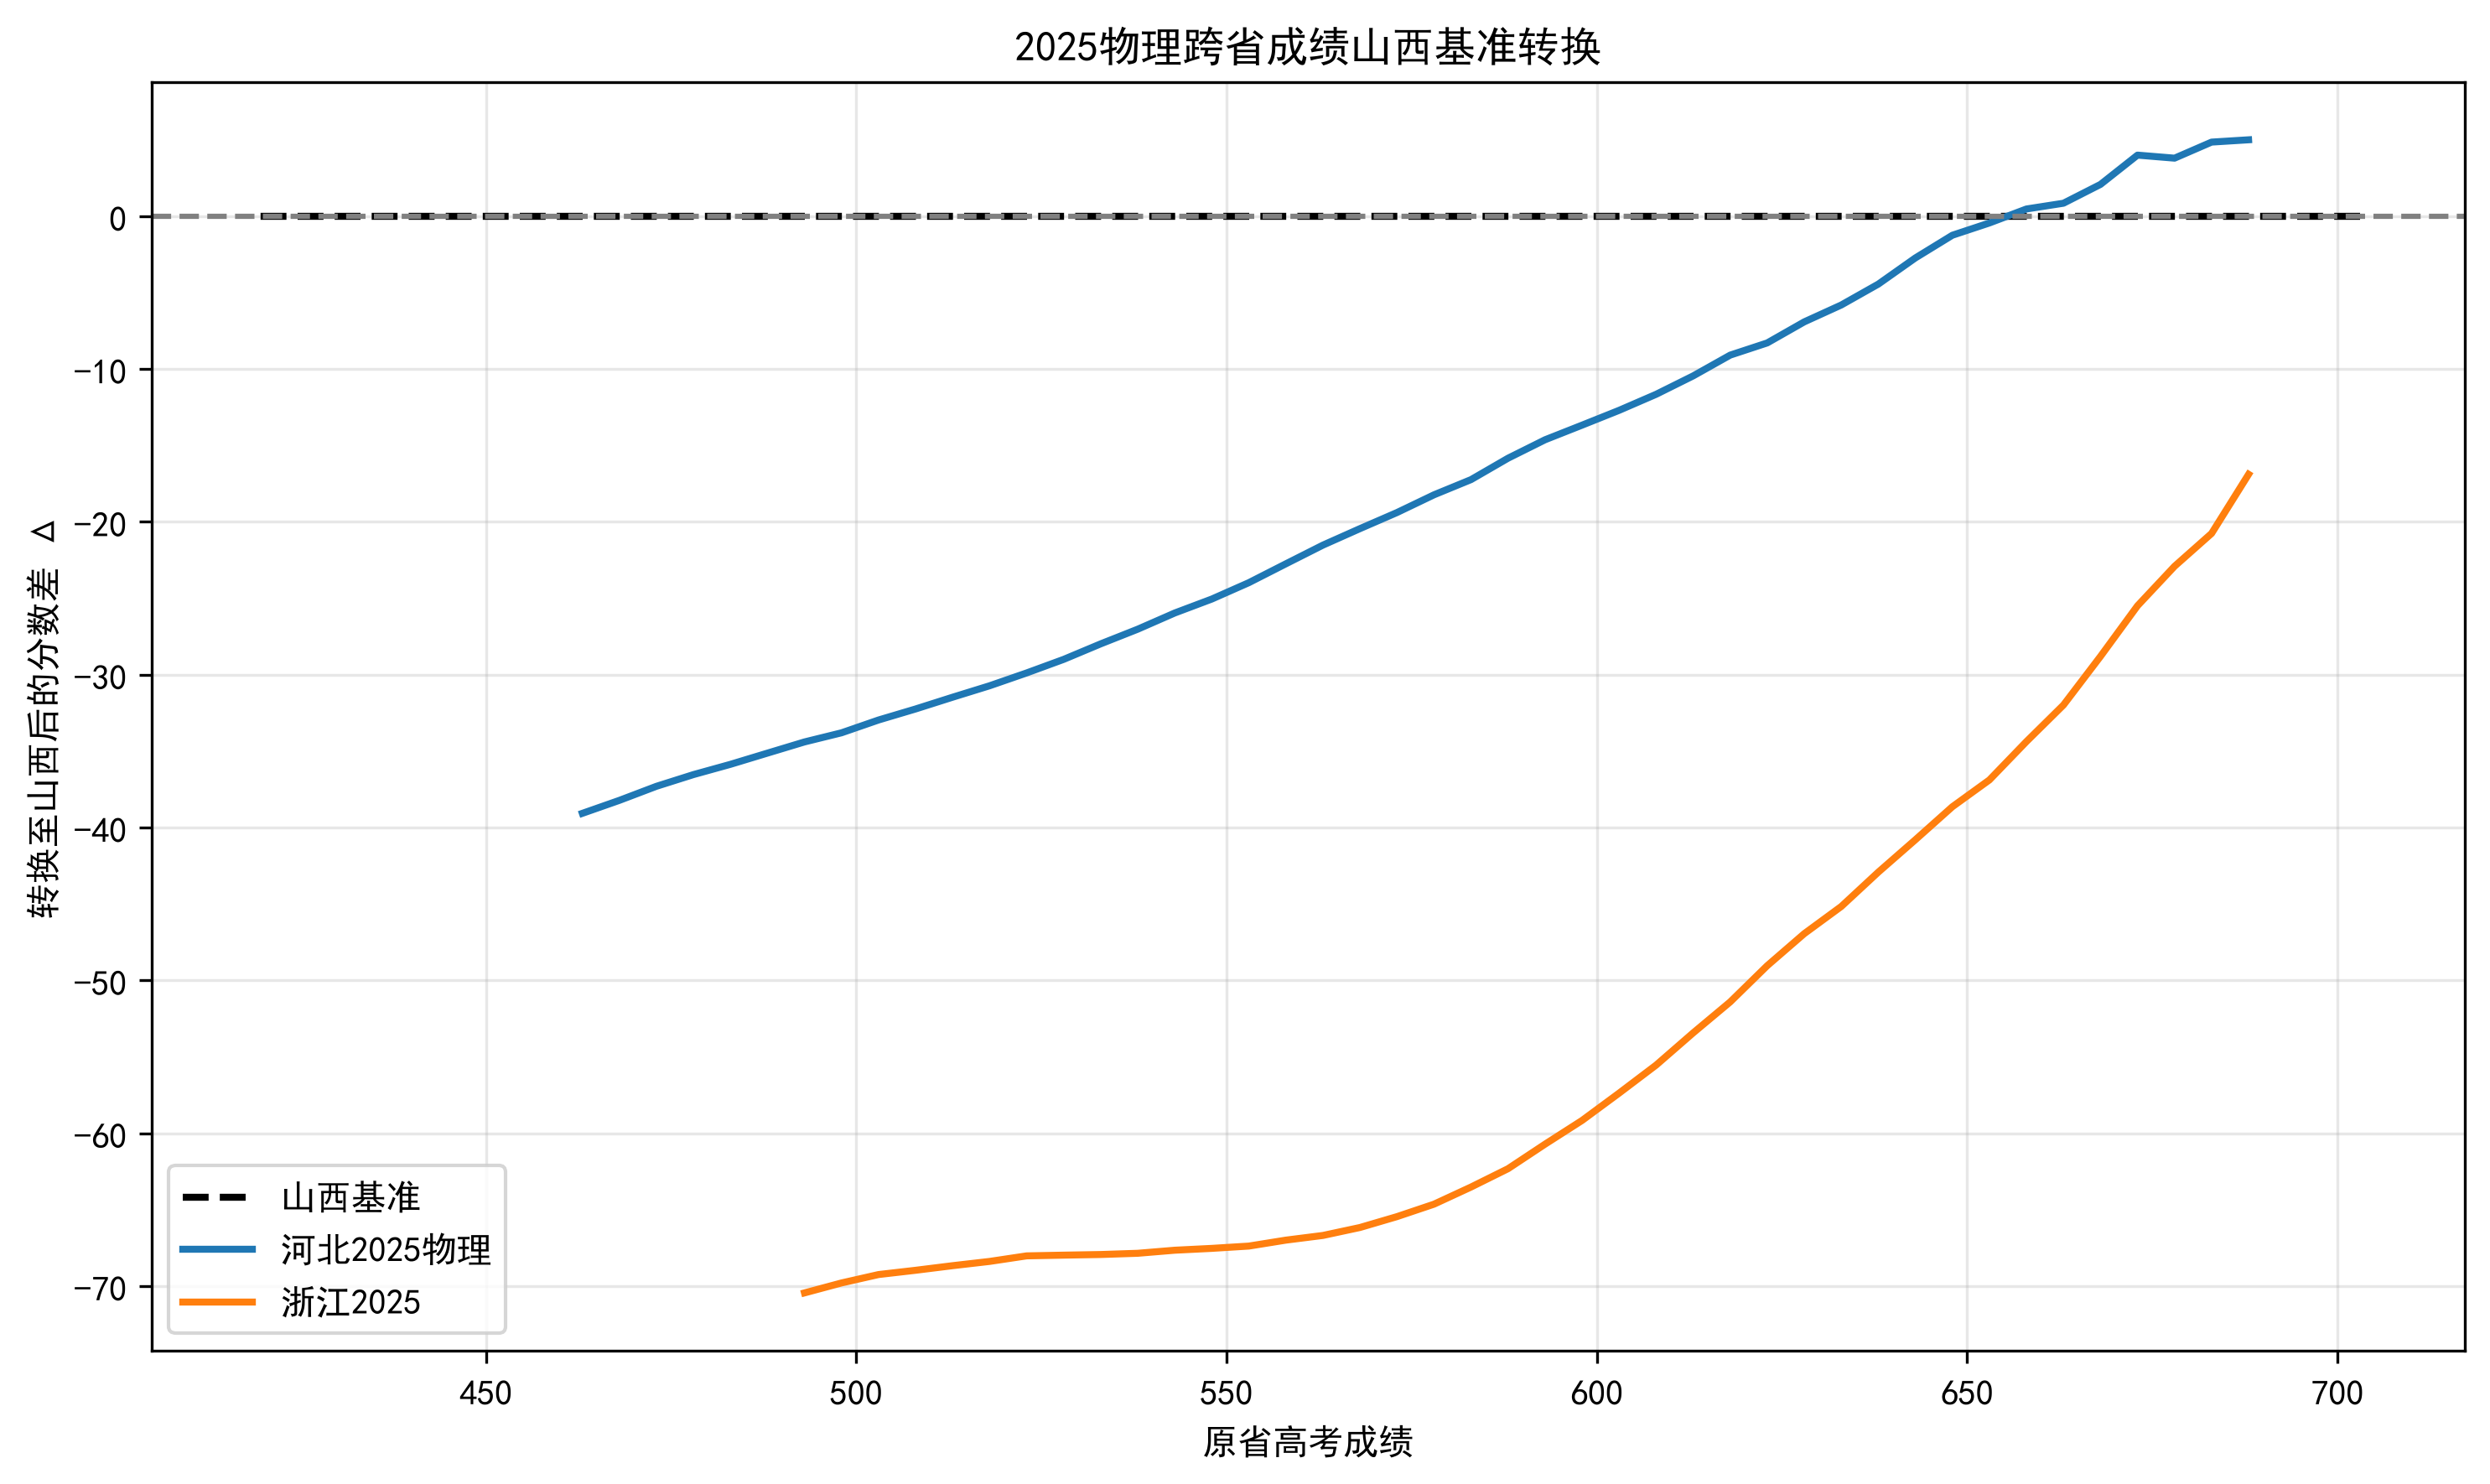

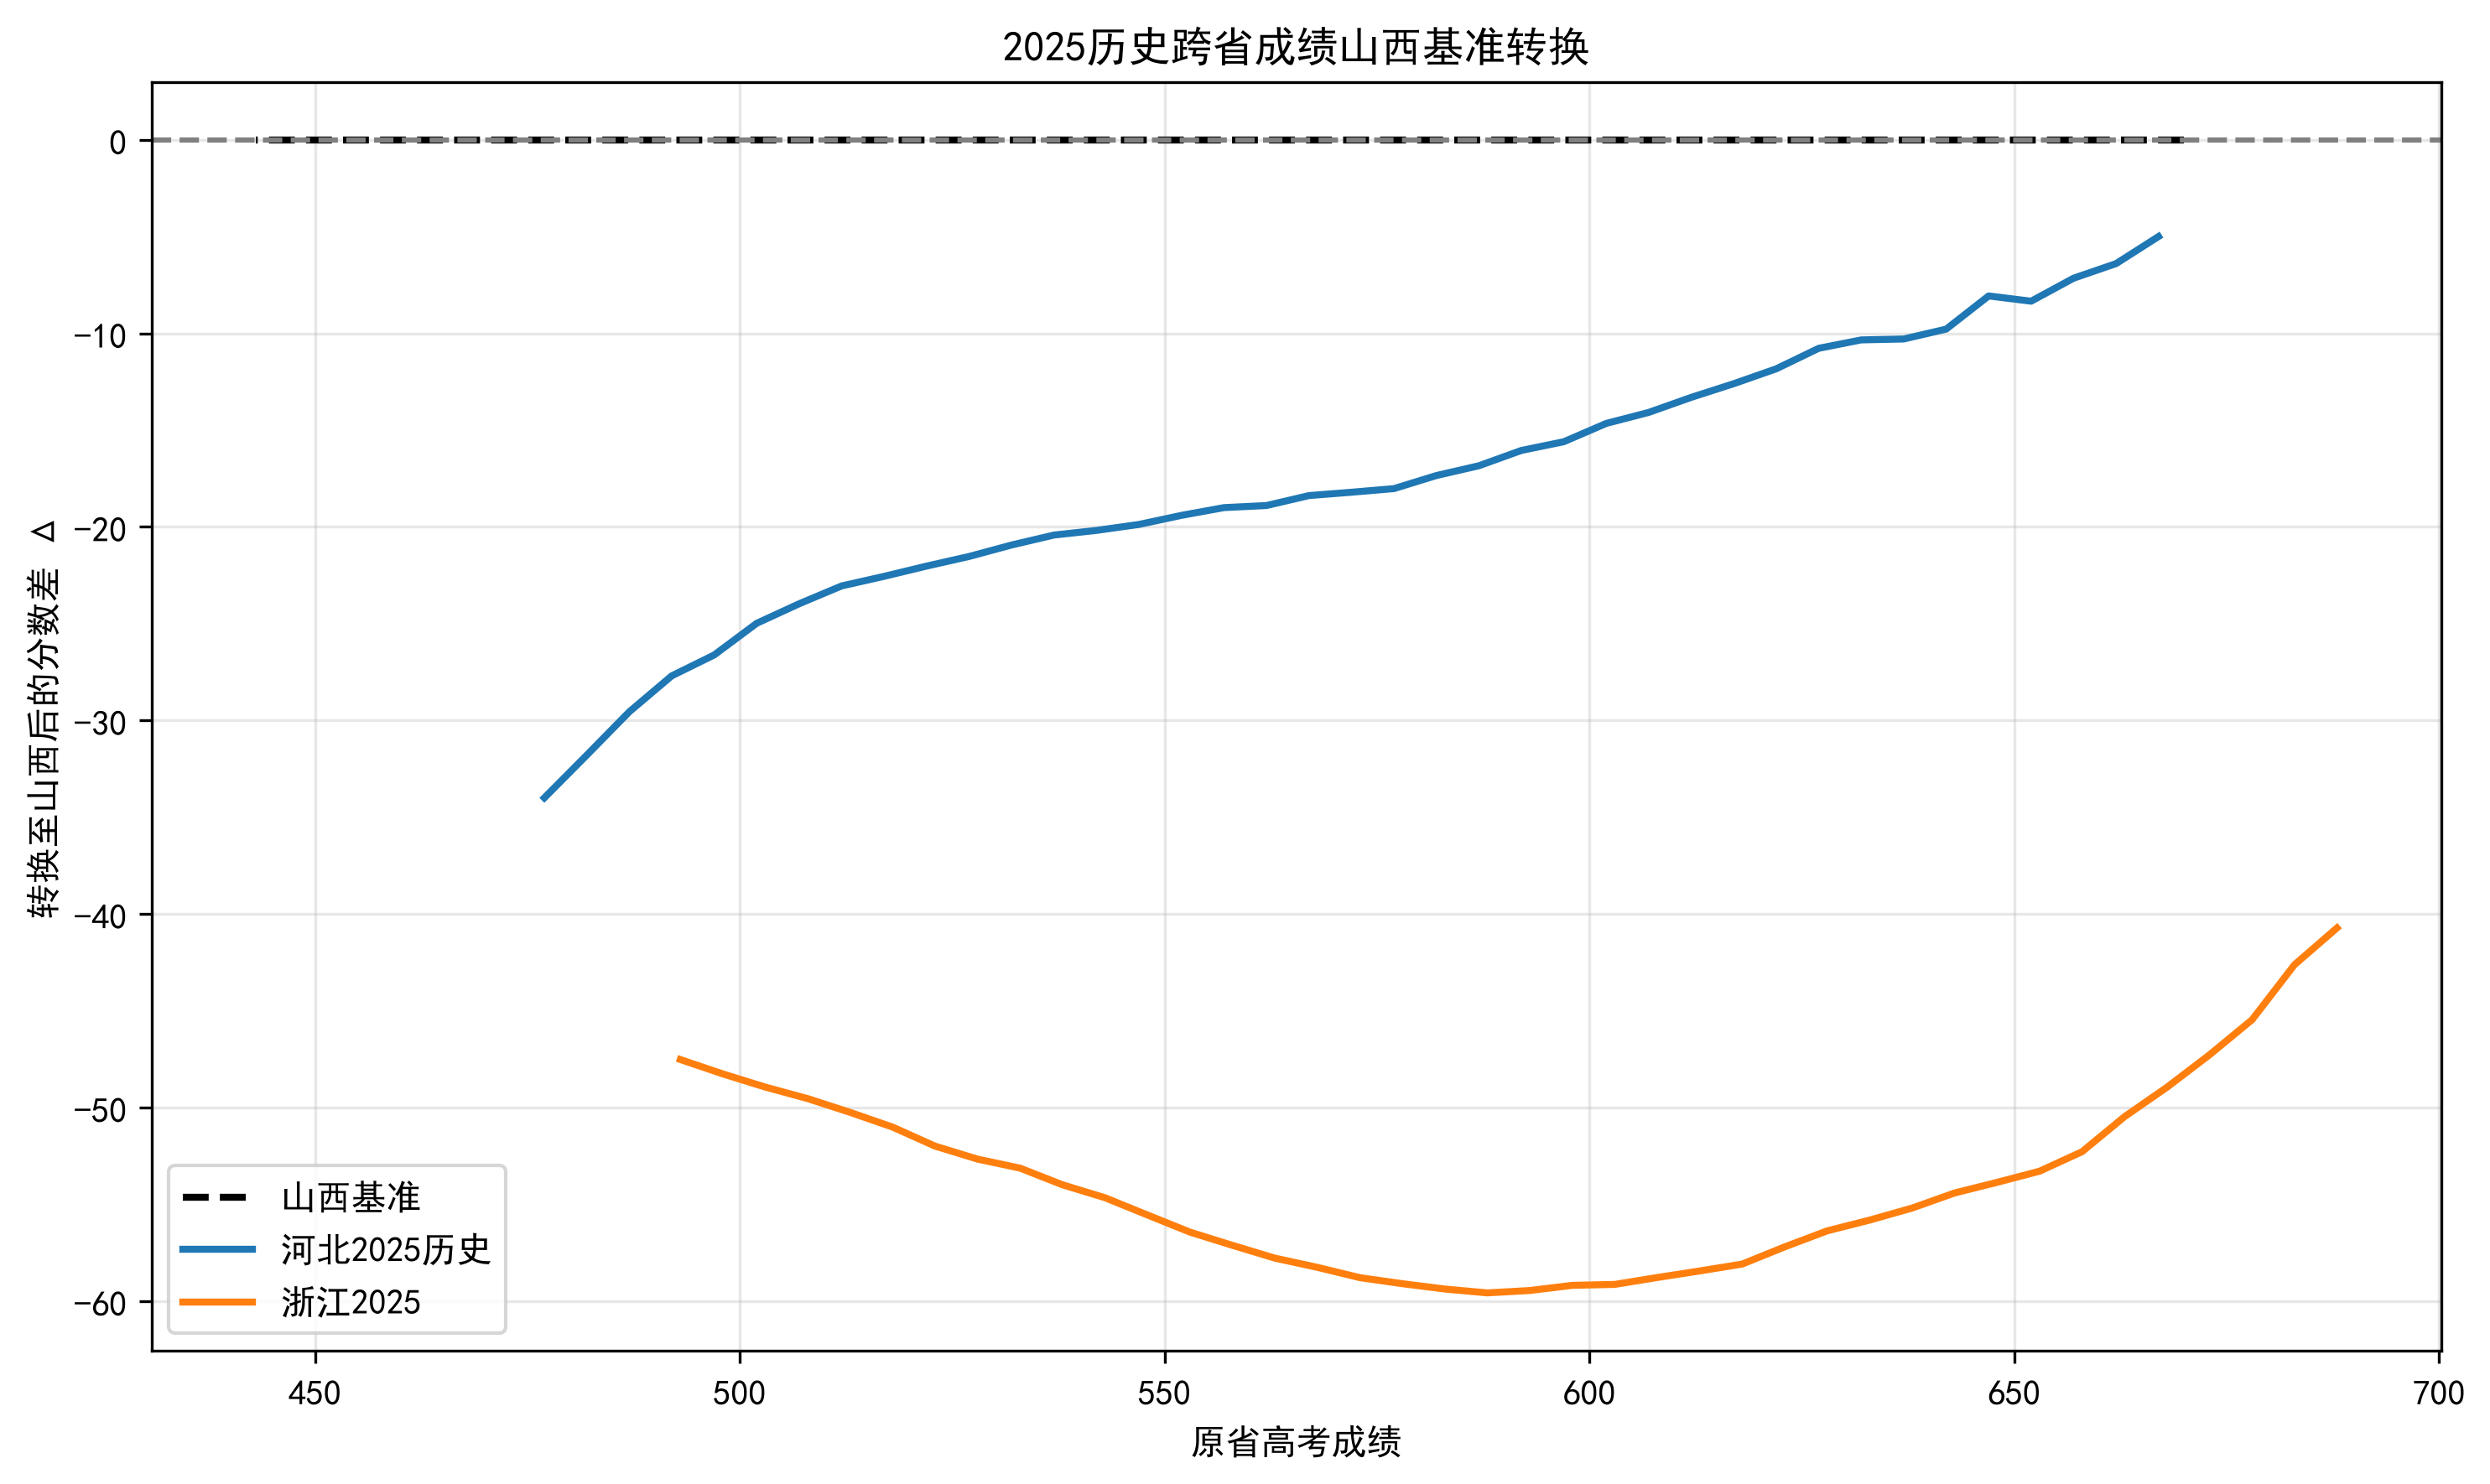

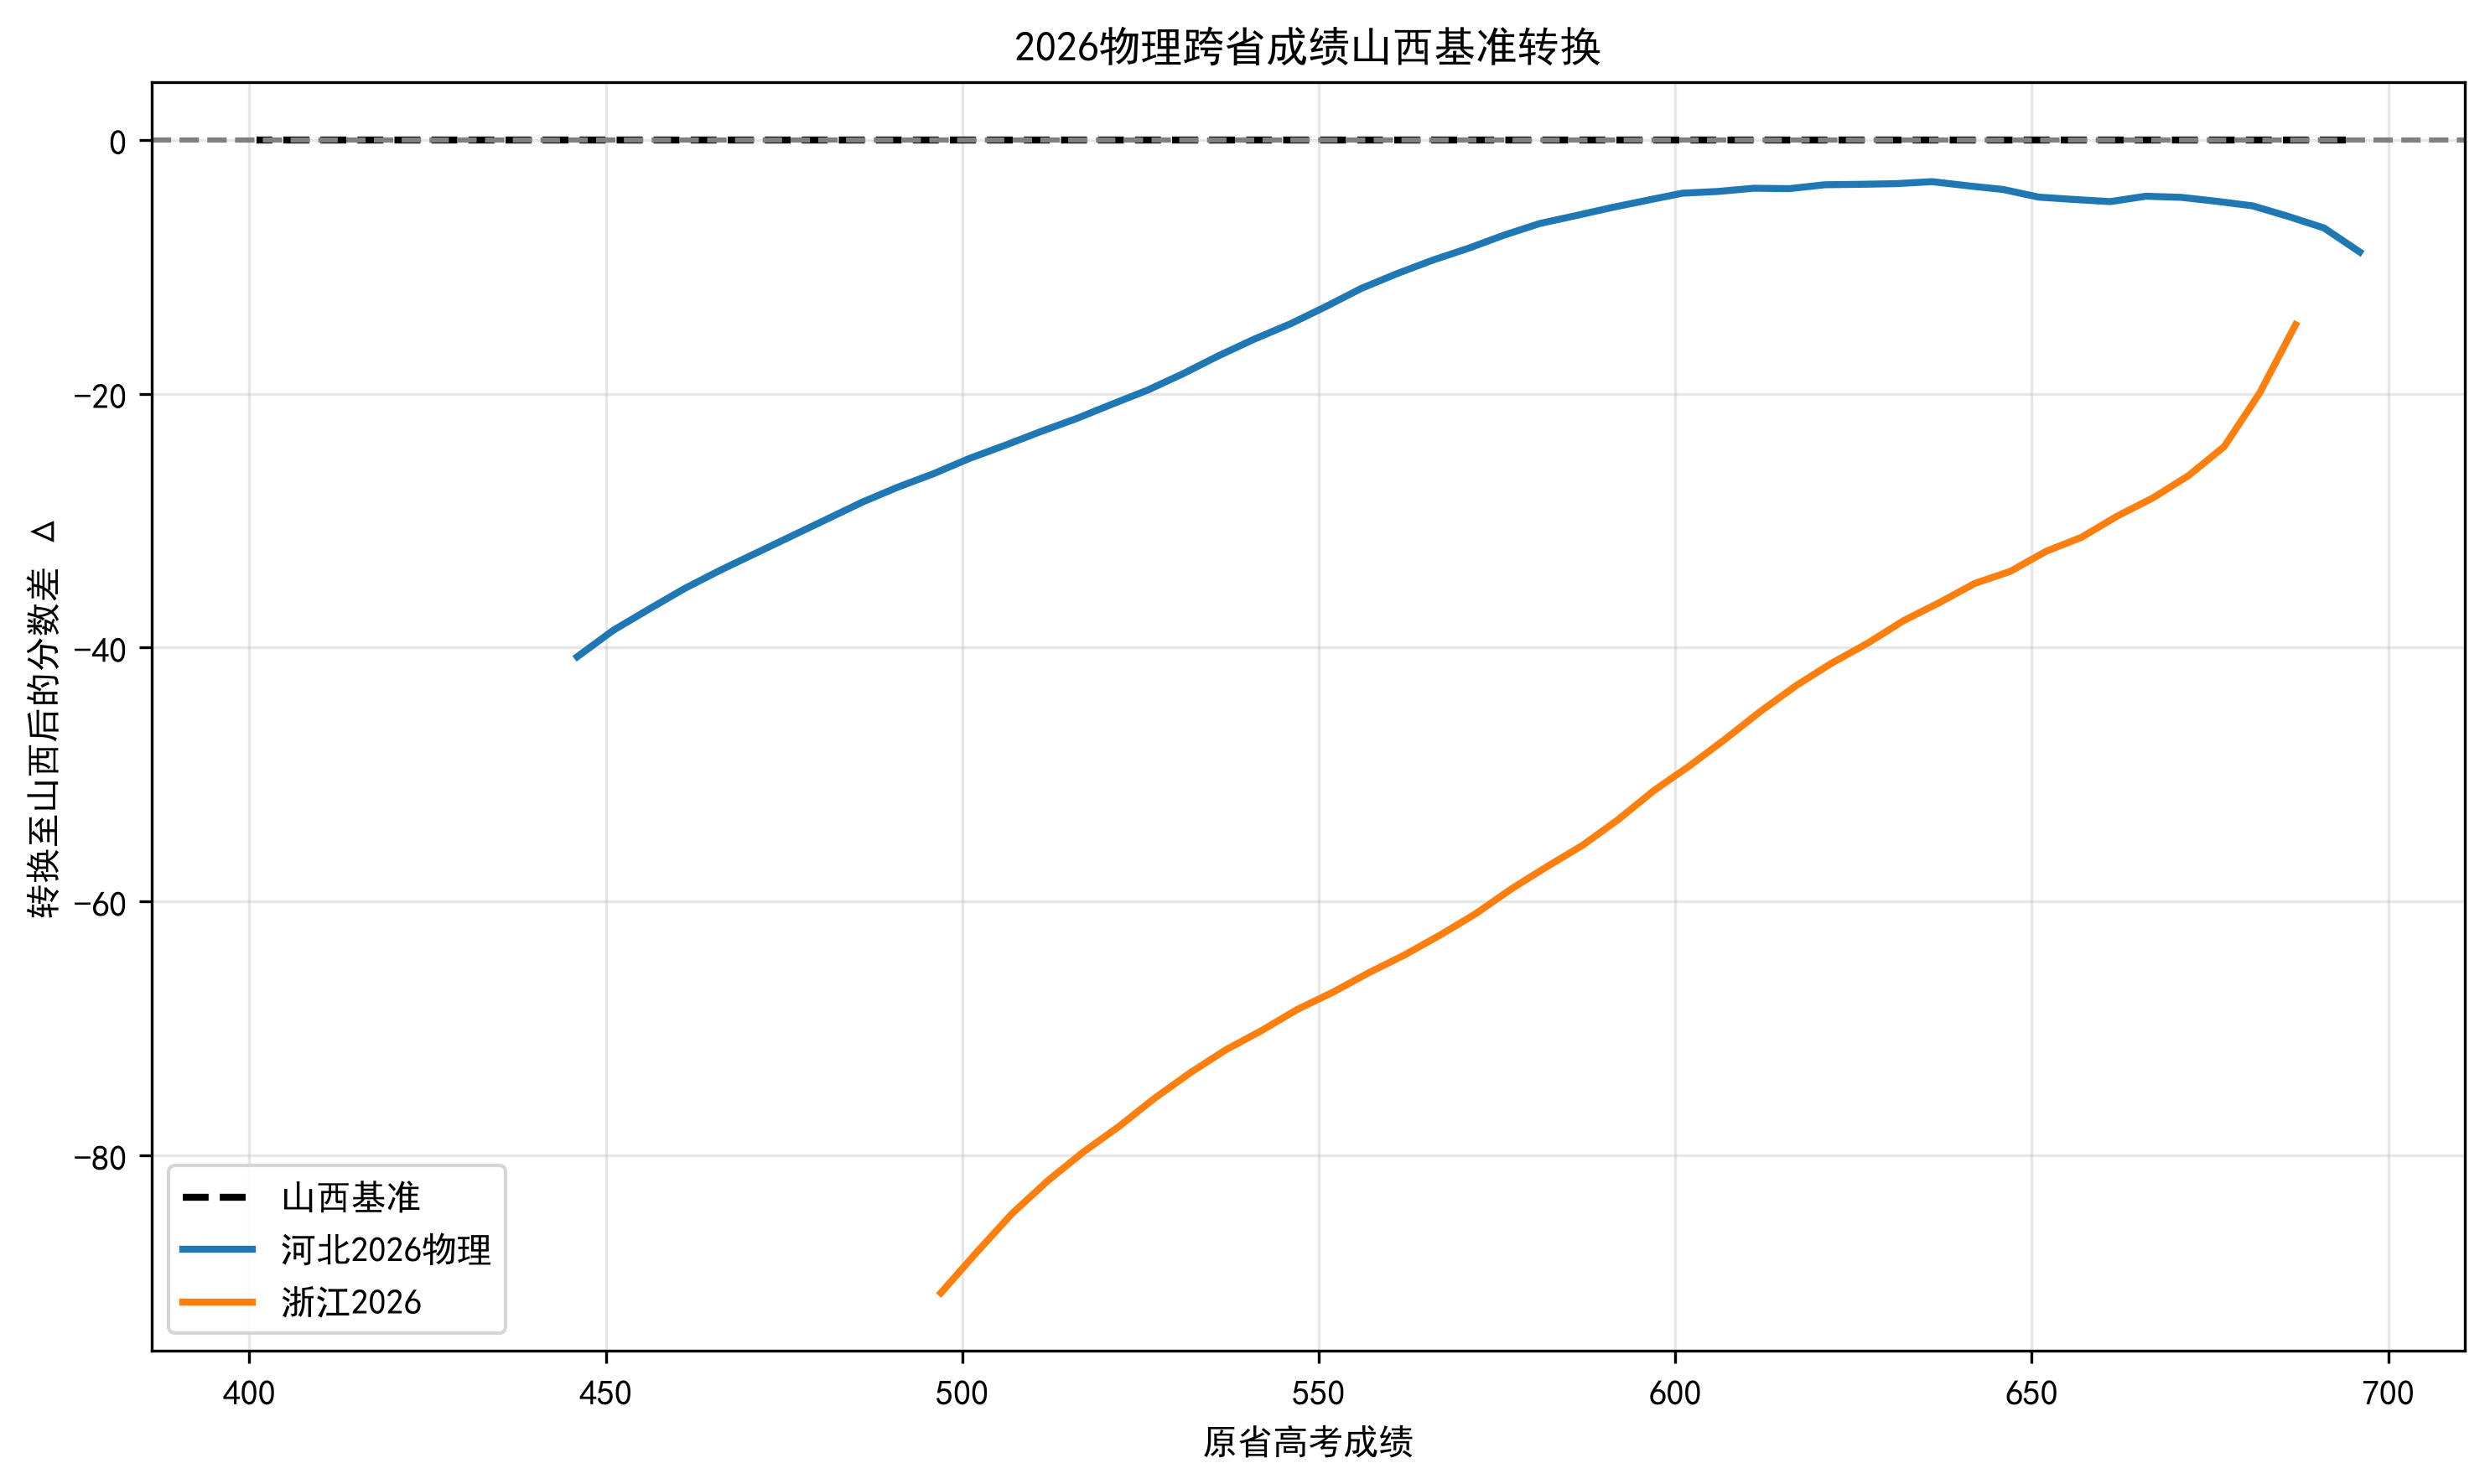

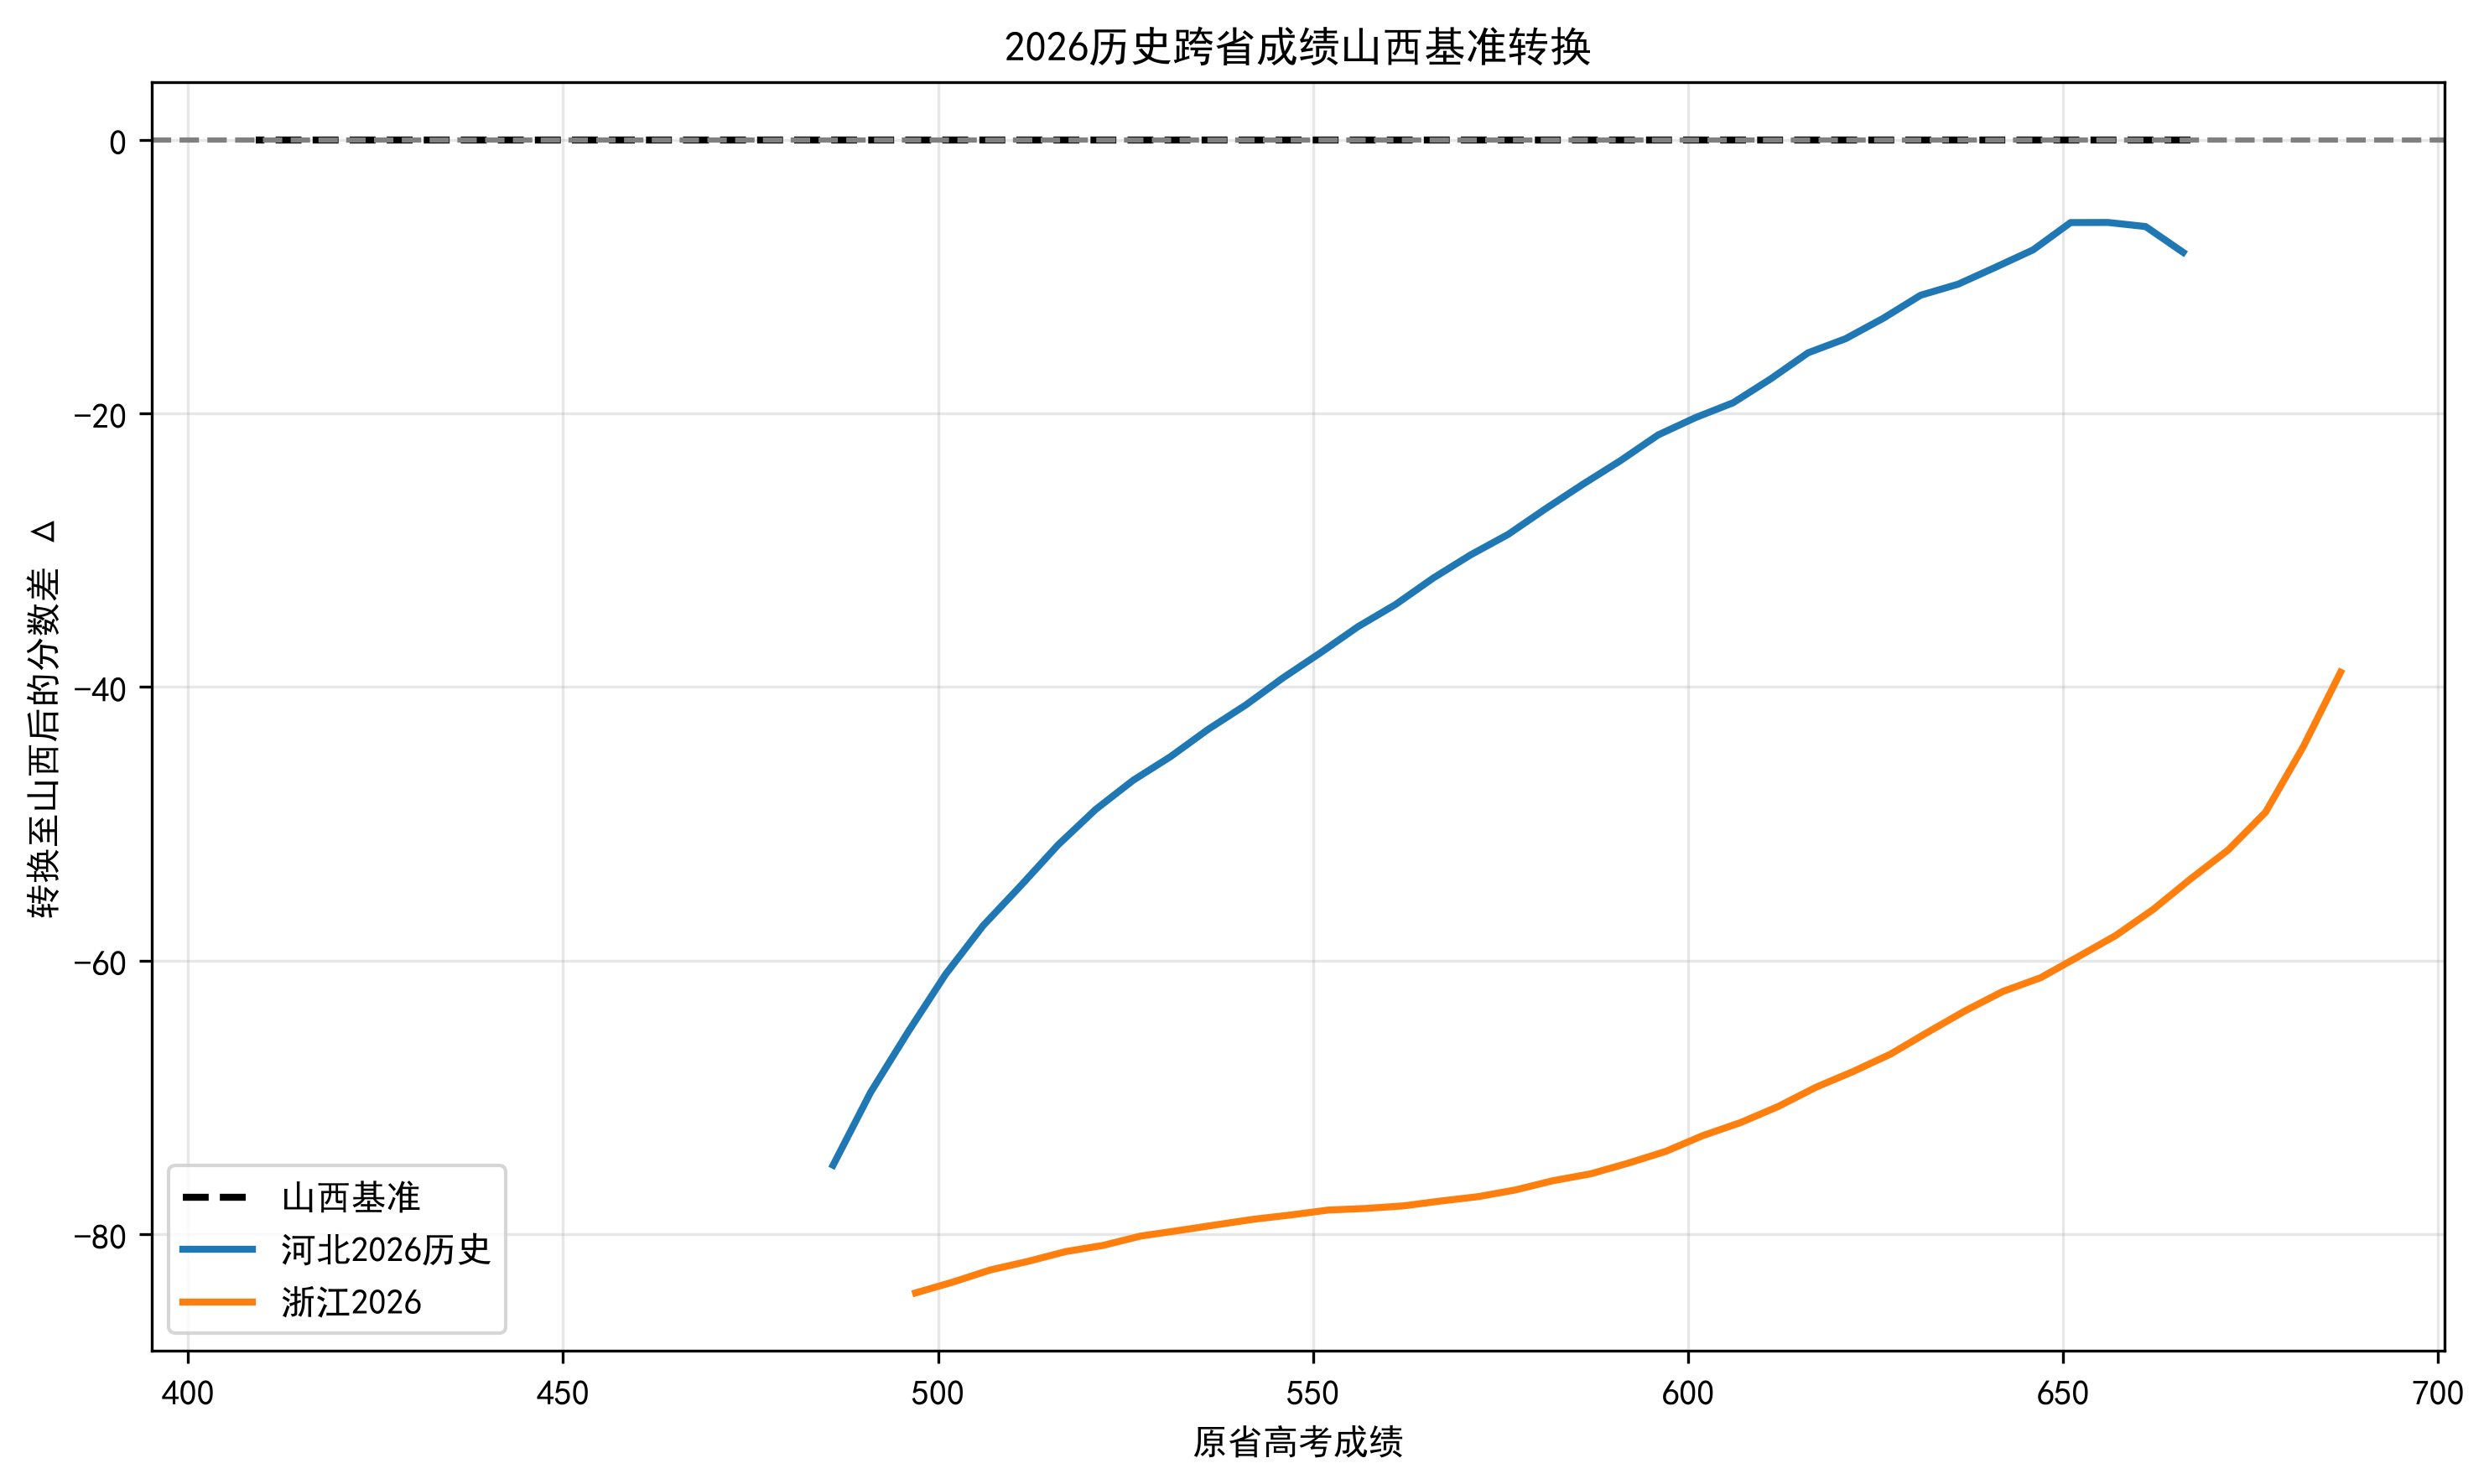

In [3]:
# =====================================================
# 问题二：
# 基于百分位保持的跨省成绩转换模型
# 山西基准评价体系
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


# =====================================================
# 中文显示
# =====================================================
plt.rcParams["font.sans-serif"]=["SimHei"]
plt.rcParams["axes.unicode_minus"]=False


# =====================================================
# 1. 文件配置
# =====================================================
files={
"山西2025物理":
"shanxi_2025_physics.csv",
"山西2025历史":
"shanxi_2025_history.csv",
"山西2026物理":
"shanxi_2026_physics.csv",
"山西2026历史":
"shanxi_2026_history.csv",
"河北2025物理":
"hebei_2025_physics.csv",
"河北2025历史":
"hebei_2025_history.csv",
"河北2026物理":
"hebei_2026_physics.csv",
"河北2026历史":
"hebei_2026_history.csv",
"浙江2025":
"zhejiang_2025.csv",
"浙江2026":
"zhejiang_2026.csv"
}


# =====================================================
# 2. 本科线
# =====================================================
line_df=pd.read_csv("undergraduate_line.csv")
cutoff=dict(zip(files.keys(),line_df["本科线"]))


# =====================================================
# 3. 读取一分一段表
# =====================================================
def load_table(file,name):
    df=pd.read_csv(file)
    df=df[["分数","本分人数"]]
    # 本科线上截断
    df=df[df["分数"]>=cutoff[name]]
    df=df.sort_values("分数",ascending=False)
    return df.reset_index(drop=True)
tables={}
for name,file in files.items():
    tables[name]=load_table(file,name)
print("数据读取完成")


# =====================================================
# 4. 构造百分位函数
# =====================================================
def build_percentile(df):
    df=df.sort_values("分数",ascending=False)
    total=df["本分人数"].sum()
    # 高分累计人数
    cum=df["本分人数"].cumsum()
    percentile=cum/total*100
    return (df["分数"].values,percentile.values)
curves={}
for name,df in tables.items():
    curves[name]=build_percentile(df)


# =====================================================
# 5. 百分位 -> 山西分数
# =====================================================
def percentile_to_score(percentile,target_curve):
    score,p=target_curve
    # 百分位递增
    order=np.argsort(p)
    p=p[order]
    score=score[order]
    f=interp1d(p,score,bounds_error=False,fill_value=(score[-1],score[0]))
    return f(percentile)


# =====================================================
# 6. 单个省份映射
# =====================================================
def convert_source_to_shanxi(source_df,source_name,target_name):
    score,p=curves[source_name]
    target_curve=curves[target_name]
    result=[]
    # 每5分一个节点
    nodes=np.arange(source_df["分数"].max(),source_df["分数"].min()-1,-5)
    for s in nodes:
        # 找最近分数
        idx=(np.abs(score-s)).argmin()
        real_score=score[idx]
        percentile=p[idx]
        shanxi_score=percentile_to_score(percentile,target_curve)
        result.append({
            "原省份":source_name,
            "原始分":real_score,
            "百分位(%)":percentile,
            "对应山西分":shanxi_score,
            "Delta":shanxi_score-real_score
        })
    return pd.DataFrame(result)


# =====================================================
# 7. 四组转换
# =====================================================
groups={"2025物理":("山西2025物理",["河北2025物理","浙江2025"]),
        "2025历史":("山西2025历史",["河北2025历史","浙江2025"]),
        "2026物理":("山西2026物理",["河北2026物理","浙江2026"]),
        "2026历史":("山西2026历史",["河北2026历史","浙江2026"])}
all_tables=[]
plot_data={}
for year,(shanxi,target_list) in groups.items():
    plot_data[year]={}
    # 山西基准线
    sx=tables[shanxi]
    plot_data[year]["山西"]=(sx["分数"].values,np.zeros(len(sx)))
    for province in target_list:
        temp=convert_source_to_shanxi(tables[province],province,shanxi)
        all_tables.append(temp)
        plot_data[year][province]=(temp["原始分"].values,temp["Delta"].values)


# =====================================================
# 10. 六对象代表性分数转换展示表
# =====================================================
target_objects=[
    "河北2025物理",
    "河北2026物理",
    "河北2025历史",
    "河北2026历史",
    "浙江2025",
    "浙江2026"]
display_tables=[]
for obj in target_objects:
    # 确定山西基准
    if "物理" in obj:
        if "2025" in obj:
            shanxi="山西2025物理"
        else:
            shanxi="山西2026物理"
    else:
        if "2025" in obj:
            shanxi="山西2025历史"
        else:
            shanxi="山西2026历史"
    # 生成完整换分结果
    temp=convert_source_to_shanxi(tables[obj],obj,shanxi)
    # 三个代表性分数
    sample_index=[
        0,          # 高分
        len(temp)//2,   # 中间
        len(temp)-1     # 本科线附近
        ]
    sample=temp.iloc[sample_index].copy()
    # 字段重新命名
    sample=sample.rename(columns={"原省份":"来源对象","原始分":"代表分数","对应山西分":"转换山西分"})
    display_tables.append(sample)
# 合并18行
final_table=pd.concat(display_tables,ignore_index=True)
# 调整字段顺序
final_table=final_table[["来源对象","代表分数","百分位(%)","转换山西分","Delta"]]
print("\n================================")
print("六对象典型分数跨省转换结果")
print("================================")
display(final_table.round(3))
# 保存
final_table.to_csv("六对象典型分数转换表.csv",index=False,encoding="utf-8-sig")
print("已生成：六对象典型分数转换表.csv")


# =====================================================
# 9. 绘制Delta曲线
# =====================================================
for year,data in plot_data.items():
    plt.figure(figsize=(10,6),dpi=300)
    for name,(x,y) in data.items():
        # 删除最高分点
        if len(x)>1:
            x=x[1:]
            y=y[1:]
        if name=="山西":
            plt.plot(x,y,color="black",linewidth=2,linestyle="--",label="山西基准")
        else:
            plt.plot(x,y,linewidth=2,label=name)
    plt.axhline(0,color="gray",linestyle="--")
    plt.xlabel("原省高考成绩")
    plt.ylabel("转换至山西后的分数差 Δ")
    plt.title(f"{year}跨省成绩山西基准转换")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [4]:
# =========================================================
# 问题二：
# 山西、河北、浙江高考竞争环境综合评价
# 5个评价对象 × 6个指标
# 熵权-TOPSIS前置矩阵构造
# =========================================================
import pandas as pd
import numpy as np
from scipy.stats import wasserstein_distance


# =========================================================
# 1. 文件配置
# =========================================================
files = {
    "山西物理":"shanxi_2025_physics.csv",
    "山西历史":"shanxi_2025_history.csv",
    "河北物理":"hebei_2025_physics.csv",
    "河北历史":"hebei_2025_history.csv",
    "浙江综合":"zhejiang_2025.csv"}


# =========================================================
# 2. 读取一分一段表
# =========================================================
def load_distribution(file):
    df=pd.read_csv(file,encoding="utf-8")
    df=df[["分数","本分人数"]]
    df=df.sort_values("分数")
    score=np.repeat(df["分数"].values,df["本分人数"].astype(int).values)
    return score
samples={}
for name,file in files.items():
    samples[name]=load_distribution(file)
print("一分一段表读取完成")


# =========================================================
# 3. X2 成绩竞争差异
# 平均 Wasserstein距离
# =========================================================
names=list(samples.keys())
W=pd.DataFrame(np.zeros((len(names),len(names))),
    index=names,
    columns=names)
for i in range(len(names)):
    for j in range(len(names)):
        W.iloc[i,j]=wasserstein_distance(samples[names[i]],samples[names[j]])
X2={}
for name in names:
    X2[name]=(W.loc[name].sum()/(len(names)-1))


# =========================================================
# 4. X3 前1%分数
# =========================================================
def top1_score(data):
    return np.percentile(data,99)
X3={}
for name,data in samples.items():
    X3[name]=top1_score(data)


# =========================================================
# 5. 读取宏观数据
# =========================================================
basic=pd.read_csv("province_competition_data.csv",encoding="utf-8")
basic.columns=basic.columns.str.strip()


# =========================================================
# 6. 读取本科线、特控线位次
# 新版 undergraduate_lines.csv
# 年份
# 省份
# 方向
# 本科线
# 本科线对应位次
# 特控线
# 特控线对应位次
# 报考人数
# =========================================================
lines=pd.read_csv("undergraduate_lines.csv",encoding="utf-8")
lines.columns=lines.columns.str.strip()
# 构造对象名称
lines["对象"]=(lines["省份"]+lines["方向"])
# 浙江特殊处理
lines.loc[lines["省份"]=="浙江","对象"]="浙江综合"


# =========================================================
# 合并位次数据
# =========================================================
basic=basic.merge(
    lines[["年份","对象","本科线对应位次","特控线对应位次"]],
    on=["年份","对象"],
    how="left")


# =========================================================
# 7. X4 本科上线率
# 原公式：
# 本科线对应位次 / 报名人数
# =========================================================
basic["X4本科上线率"]=(basic["本科线对应位次"]/basic["报名人数"])


# =========================================================
# 8. X5 特控上线率
# 原公式：
# 特控线对应位次 / 报名人数
# =========================================================
basic["X5特控上线率"]=(basic["特控线对应位次"]/basic["报名人数"])


# =========================================================
# 9. X6 本科资源供给
# 本科招生计划 / 报名人数
# =========================================================
basic["X6本科资源供给"]=(basic["本科招生计划"]/basic["报名人数"])


# =========================================================
# 10. X1报名人数
# =========================================================
basic["X1报名人数"]=basic["报名人数"]


# =========================================================
# 11. 合并X2、X3
# =========================================================
basic["X2成绩竞争差异"]=(basic["对象"].map(X2))
basic["X3前1%分数"]=(basic["对象"].map(X3))


# =========================================================
# 12. 输出5×6指标矩阵
# =========================================================
result=basic[["年份","对象","X1报名人数","X2成绩竞争差异","X3前1%分数","X4本科上线率","X5特控上线率","X6本科资源供给"]]
print("\n==============================")
print("最终评价指标矩阵")
print("==============================")
display(result.round(4))
# 保存
result.to_csv("TOPSIS_input_matrix.csv",index=False,encoding="utf-8-sig")
print("已生成 TOPSIS_input_matrix.csv")

一分一段表读取完成

最终评价指标矩阵


,年份,对象,X1报名人数,X2成绩竞争差异,X3前1%分数,X4本科上线率,X5特控上线率,X6本科资源供给
0,2025,山西物理,184809,45.9737,655.0,0.6509,0.3007,0.4221
1,2025,山西历史,106652,51.0650,633.0,0.3364,0.1094,0.3375
2,2025,河北物理,363040,46.7528,648.0,0.6176,0.4469,0.5454
3,2025,河北历史,243714,103.8766,620.0,0.2663,0.1393,0.3365
4,2025,浙江综合,402000,54.3363,673.0,0.4586,0.1533,0.6269
5,2026,山西物理,167419,45.9737,655.0,0.7727,0.3195,0.4181
6,2026,山西历史,63113,51.0650,633.0,0.5607,0.1349,0.3327
7,2026,河北物理,350991,46.7528,648.0,0.6764,0.4081,0.5413
8,2026,河北历史,231476,103.8766,620.0,0.2766,0.1212,0.3370
9,2026,浙江综合,405000,54.3363,673.0,0.4563,0.1523,0.6247


已生成 TOPSIS_input_matrix.csv



==========熵权结果==========


,指标,权重
0,X1报名人数,0.1060
1,X2成绩竞争差异,0.4157
2,X3前1%分数,0.1436
3,X4本科上线率,0.1057
4,X5特控上线率,0.0955
5,X6本科资源供给,0.1335



==========物理方向高考难度排名==========


,年份,方向,对象,TOPSIS难度指数,排名
4,2025,物理方向,浙江综合,0.3606,4
0,2025,物理方向,山西物理,0.2509,7
2,2025,物理方向,河北物理,0.2264,9
9,2026,物理方向,浙江综合,0.3616,3
5,2026,物理方向,山西物理,0.2431,8
7,2026,物理方向,河北物理,0.2209,10



==========历史方向高考难度排名==========


,年份,方向,对象,TOPSIS难度指数,排名
3,2025,历史方向,河北历史,0.7514,1
4,2025,历史方向,浙江综合,0.3606,4
1,2025,历史方向,山西历史,0.3230,5
8,2026,历史方向,河北历史,0.7501,2
9,2026,历史方向,浙江综合,0.3616,3
6,2026,历史方向,山西历史,0.2959,6



==========2025-2026变化==========


年份,2025,2026,变化量
对象,,,
山西历史,0.3230,0.2959,-0.0271
山西物理,0.2509,0.2431,-0.0078
河北历史,0.7514,0.7501,-0.0014
河北物理,0.2264,0.2209,-0.0055
浙江综合,0.3606,0.3616,0.0010


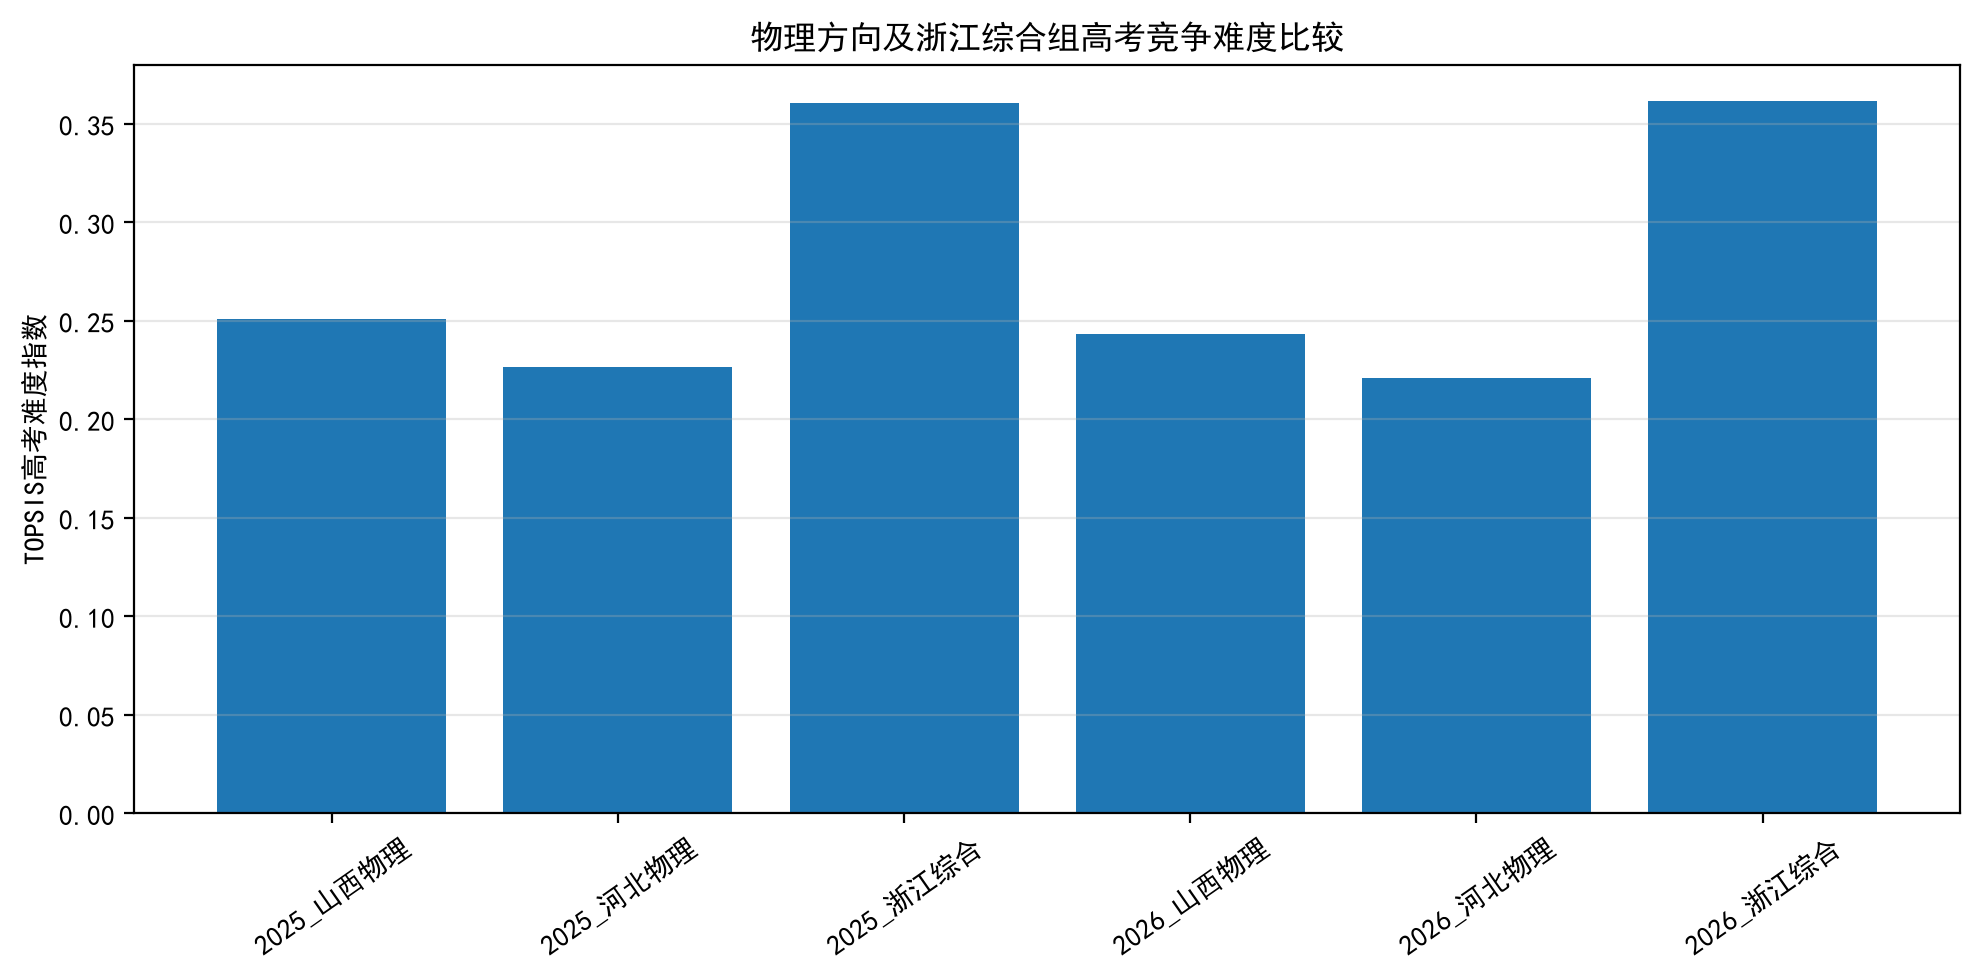

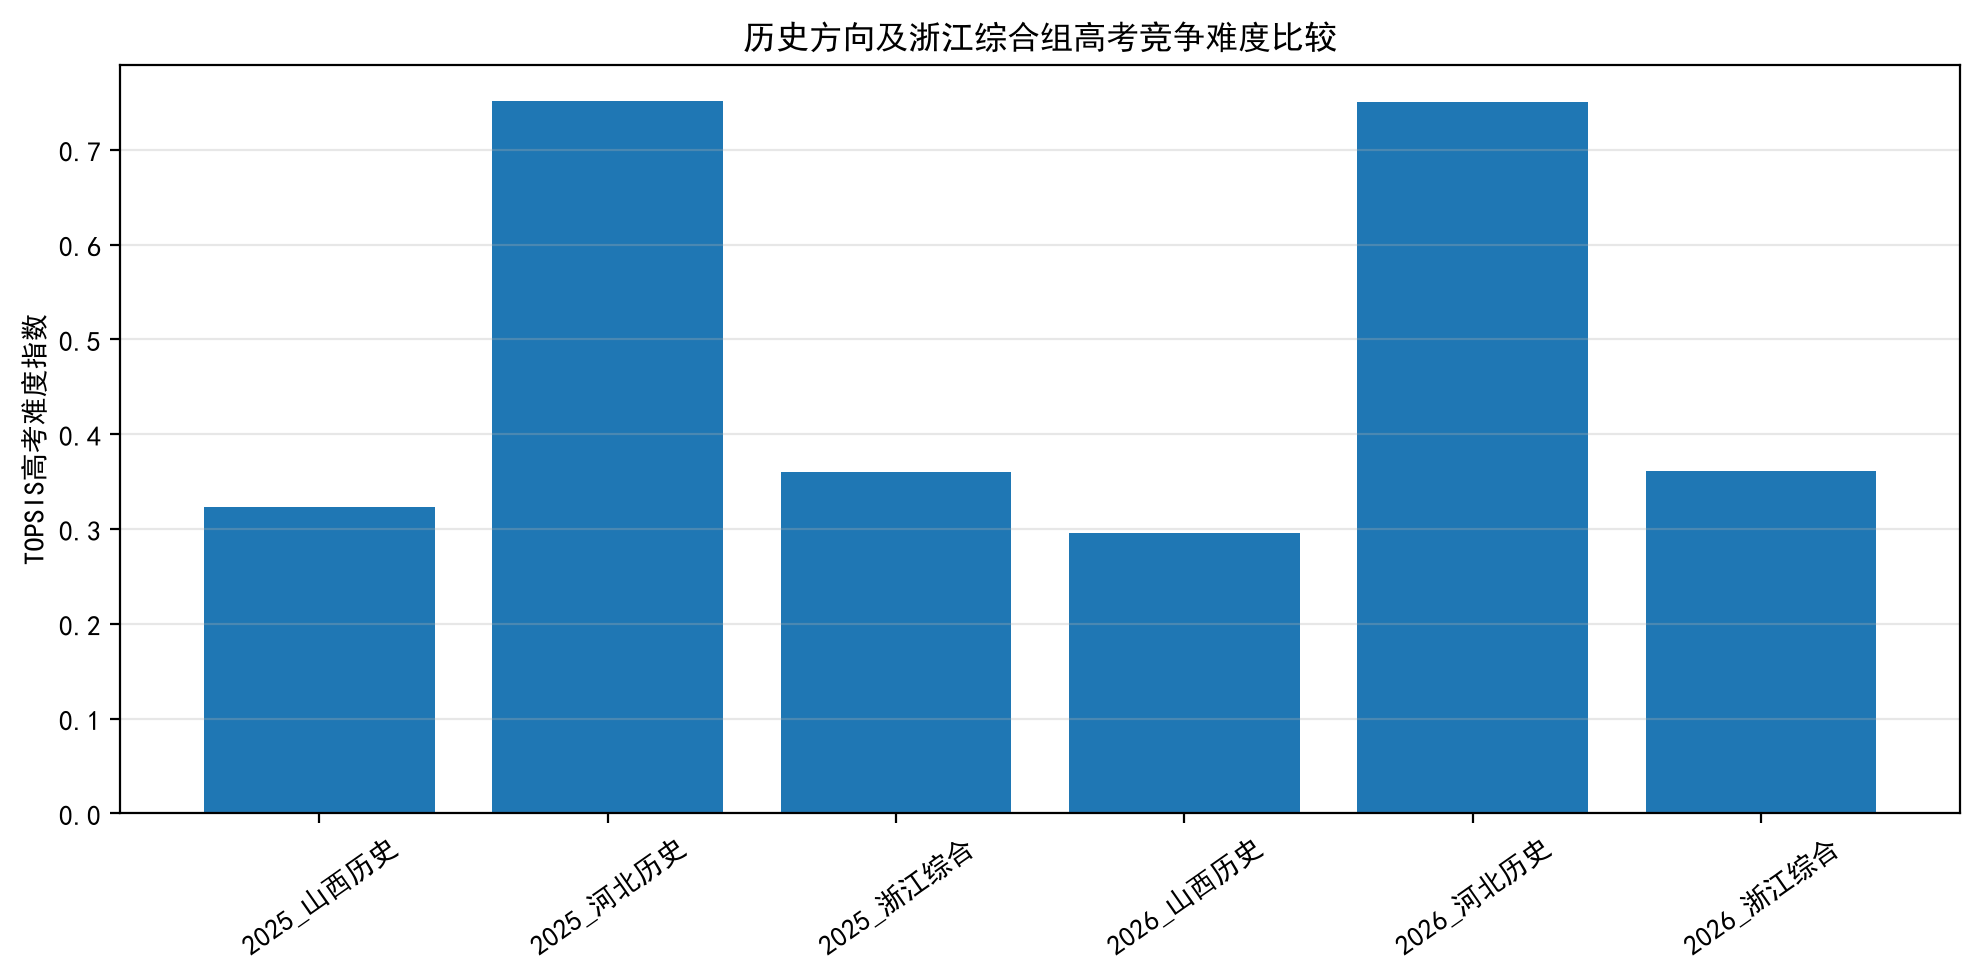

In [5]:
# ======================================================
# 新高考背景下省际高考竞争难度评价
# 熵权法 + TOPSIS
# 输入:
# TOPSIS_input_matrix.csv
# 输出:
# TOPSIS_result.csv
# 指标权重
# 物理方向排名
# 历史方向排名
# 两张比较图
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ======================================================
# 中文显示
# ======================================================
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False


# ======================================================
# 1.读取指标矩阵
# ======================================================
df = pd.read_csv("TOPSIS_input_matrix.csv",encoding="utf-8-sig")
df.columns = df.columns.str.strip()


# ======================================================
# 2. 指标定义
# ======================================================
indicators=["X1报名人数","X2成绩竞争差异","X3前1%分数","X4本科上线率","X5特控上线率","X6本科资源供给"]
X=df[indicators].values


# ======================================================
# 3. 指标方向处理
# ======================================================
# 难度评价：
# 正向：
# X1 报名人数
# X2 成绩竞争差异
# X3 前1%分数
# 负向：
# X4 本科上线率
# X5 特控上线率
# X6 本科资源供给
negative_index=[3,4,5]
X_adj=X.copy()
for i in negative_index:
    X_adj[:,i]=(X_adj[:,i].max()-X_adj[:,i])


# ======================================================
# 4. 标准化
# ======================================================
Z=np.zeros_like(X_adj,dtype=float)
for j in range(X_adj.shape[1]):
    Z[:,j]=(X_adj[:,j]-X_adj[:,j].min())/(X_adj[:,j].max()-X_adj[:,j].min()+1e-12)


# ======================================================
# 5. 熵权法
# ======================================================
P=Z/(Z.sum(axis=0)+1e-12)
n=len(Z)
entropy=[]
for j in range(Z.shape[1]):
    e=-(1/np.log(n))*np.sum(P[:,j]*np.log(P[:,j]+1e-12))
    entropy.append(e)
entropy=np.array(entropy)
difference=1-entropy
weight=difference/difference.sum()
weight_df=pd.DataFrame({"指标":indicators,"权重":weight})
print("\n==========熵权结果==========")
display(weight_df.round(4))


# ======================================================
# 6. TOPSIS计算
# ======================================================
V=Z*weight
ideal_best=V.max(axis=0)
ideal_worst=V.min(axis=0)
D_best=np.sqrt(((V-ideal_best)**2).sum(axis=1))
D_worst=np.sqrt(((V-ideal_worst)**2).sum(axis=1))
score=(D_worst/(D_best+D_worst))


# ======================================================
# 7. 保存TOPSIS结果
# ======================================================
result=pd.DataFrame({"年份":df["年份"],"对象":df["对象"],"TOPSIS难度指数":score})
result["排名"]=result["TOPSIS难度指数"].rank(ascending=False).astype(int)
result.to_csv("TOPSIS_result.csv",
index=False,encoding="utf-8-sig")


# ======================================================
# 8. 输出物理方向排名
# 包含浙江综合
# ======================================================
physics_rank=result[result["对象"].isin(["山西物理","河北物理","浙江综合"])].copy()
physics_rank=physics_rank.sort_values(["年份","TOPSIS难度指数"],ascending=[True,False])
physics_rank.insert(1,"方向","物理方向")
print("\n==========物理方向高考难度排名==========")
display(physics_rank.round(4))


# ======================================================
# 9. 输出历史方向排名
# 包含浙江综合
# ======================================================
history_rank=result[result["对象"].isin(["山西历史","河北历史","浙江综合"])].copy()
history_rank=history_rank.sort_values(["年份","TOPSIS难度指数"],ascending=[True,False])
history_rank.insert(1,"方向","历史方向")
print("\n==========历史方向高考难度排名==========")
display(history_rank.round(4))


# ======================================================
# 10. 年度变化
# ======================================================
change=result.pivot(index="对象",columns="年份",values="TOPSIS难度指数")
change["变化量"]=change[2026]-change[2025]
print("\n==========2025-2026变化==========")
display(change.round(4))


# ======================================================
# 11. 物理方向柱状图
# ======================================================
physics_plot=result[result["对象"].isin(["山西物理","河北物理","浙江综合"])]
plt.figure(figsize=(10,5),dpi=200)
plt.bar(physics_plot["年份"].astype(str)+"_"+physics_plot["对象"],physics_plot["TOPSIS难度指数"])
plt.ylabel("TOPSIS高考难度指数")
plt.title("物理方向及浙江综合组高考竞争难度比较")
plt.xticks(rotation=35)
plt.grid(axis="y",alpha=0.3)
plt.tight_layout()
plt.show()


# ======================================================
# 12. 历史方向柱状图
# ======================================================
history_plot=result[result["对象"].isin(["山西历史","河北历史","浙江综合"])]
plt.figure(figsize=(10,5),dpi=200)
plt.bar(history_plot["年份"].astype(str)+"_"+history_plot["对象"],history_plot["TOPSIS难度指数"])
plt.ylabel("TOPSIS高考难度指数")
plt.title("历史方向及浙江综合组高考竞争难度比较")
plt.xticks(rotation=35)
plt.grid(axis="y",alpha=0.3)
plt.tight_layout()
plt.show()